In [1]:
#ignore the warnings , i plan to improve my pipeline and hypertune the parameters in future
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
qdf= pd.read_csv('insurance.csv',na_values = "x")
null=qdf.isnull()
qdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
dqdf=qdf.drop(['sex','smoker','region'],axis=1)
qX=dqdf.iloc[:,:3]
qX.info()
qY=dqdf.iloc[:,-1]
qY.info()
qxtrain,qxtest,qytrain,qytest=train_test_split(qX,qY,test_size=0.1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   bmi       1338 non-null   float64
 2   children  1338 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 31.5 KB
<class 'pandas.core.series.Series'>
RangeIndex: 1338 entries, 0 to 1337
Series name: charges
Non-Null Count  Dtype  
--------------  -----  
1338 non-null   float64
dtypes: float64(1)
memory usage: 10.6 KB


In [4]:
#Testing accuracy with reduced parameters
qclf = LinearRegression()
qclf.fit(qxtrain,qytrain)
qypred = qclf.predict(qxtest)
a = r2_score(qytest,qypred)
print(a*100,'%')

0.7469187862623627 %


In [5]:
df = pd.read_csv('insurance.csv',na_values = "x")
df = df.drop(['region'],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 62.8+ KB


<Axes: ylabel='Density'>

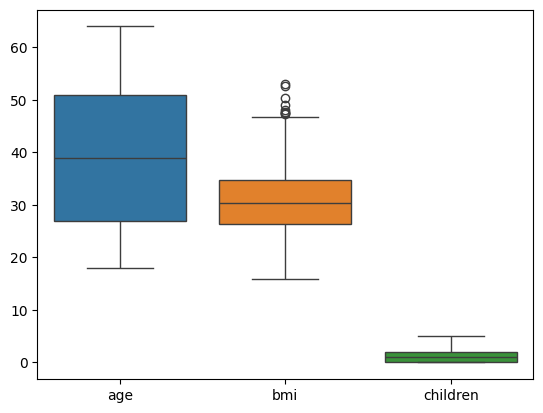

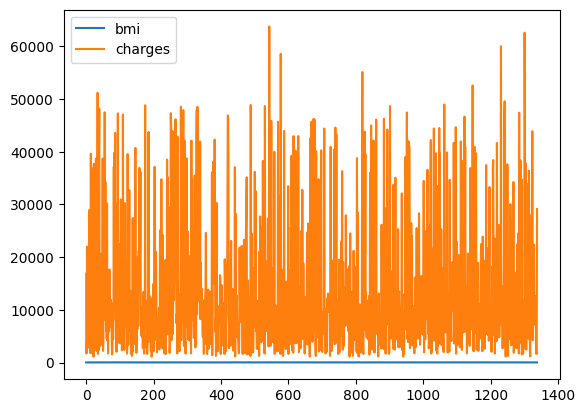

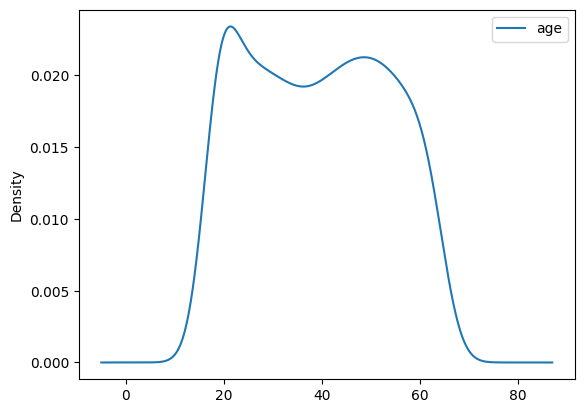

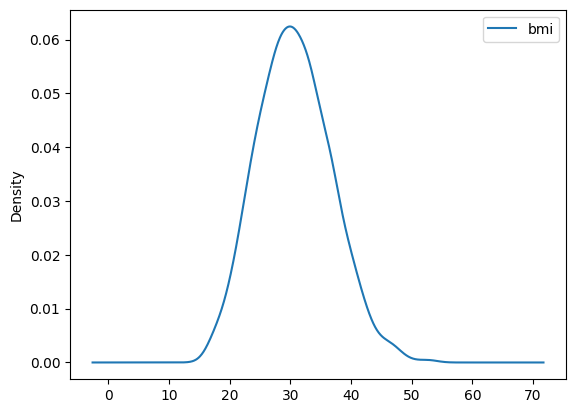

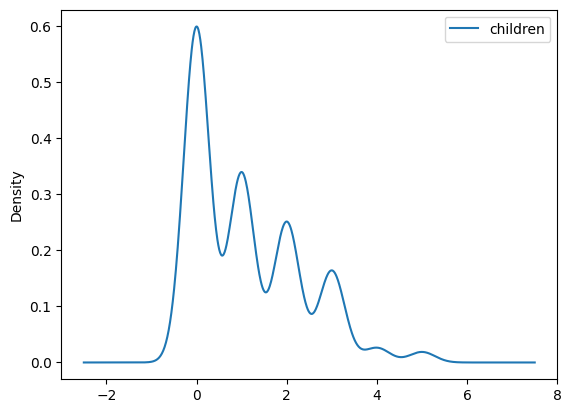

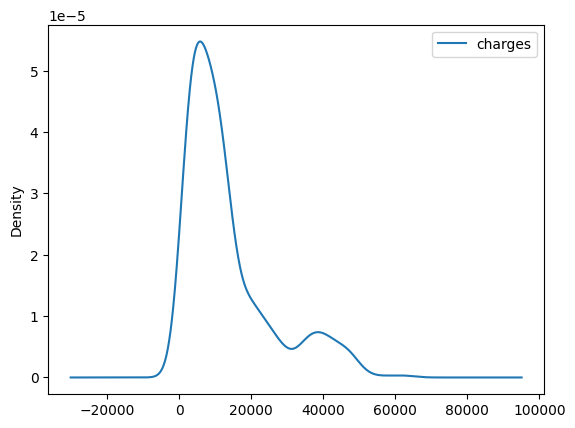

In [6]:
a = [df.age,df.bmi,df.children]
sns.boxplot(a)
df.plot(y=['bmi','charges'], kind='line')
df.plot(y=['age'], kind='kde')
df.plot(y=['bmi'], kind='kde')
df.plot(y=['children'], kind='kde')
df.plot(y=['charges'], kind='kde')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   bmi       1338 non-null   float64
 2   children  1338 non-null   int64  
 3   charges   1338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 41.9 KB
           age       bmi  children   charges
0    -1.616161 -0.409919 -1.074893  0.681663
1    -1.616161  0.548954  0.300468 -1.748842
2    -0.762769  0.428603  1.367452 -0.768811
3    -0.379090 -1.353878 -1.074893  0.978834
4    -0.454018 -0.242750 -1.074893 -0.916592
...        ...       ...       ...       ...
1333  0.789018  0.103843  1.367452  0.165749
1334 -1.616161  0.257211 -1.074893 -1.498613
1335 -1.616161  1.016092 -1.074893 -1.806594
1336 -1.345310 -0.779098 -1.074893 -1.594756
1337  1.465761 -0.210694 -1.074893  1.299963

[1338 rows x 4 columns]

 [ 0.62131046  0.44317227 -0.36627265  0.04

<Axes: ylabel='Density'>

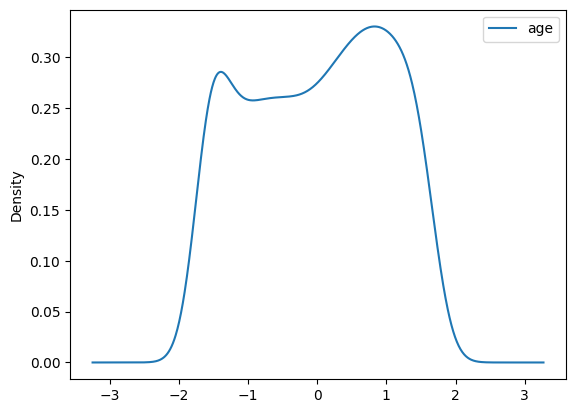

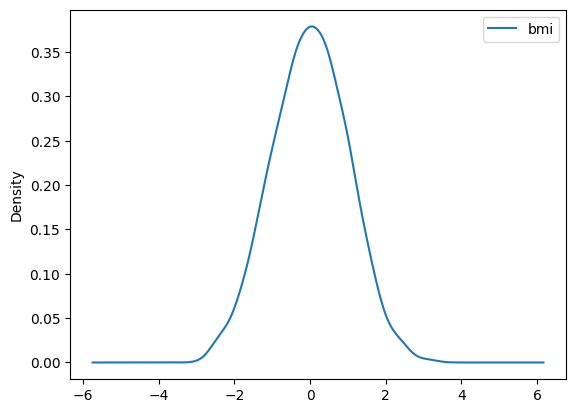

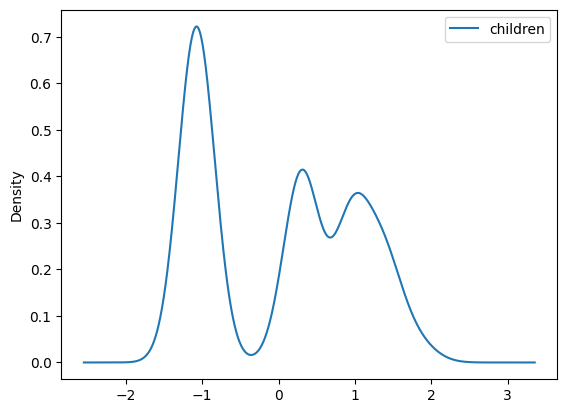

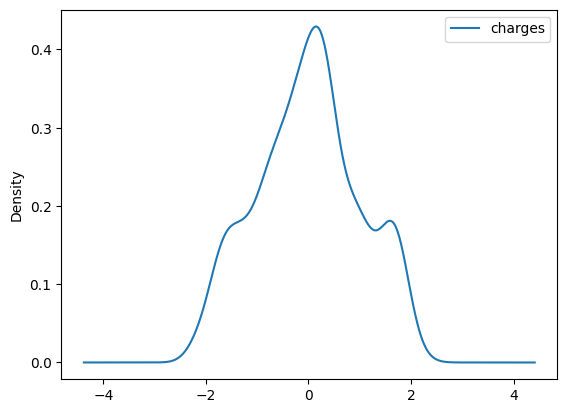

In [7]:
transf = df.drop(['sex','smoker',],axis=1)
transf.info()
pt = PowerTransformer(method='yeo-johnson', standardize=True)
transformed = pt.fit_transform(transf)
print(transformed)
print('\n',pt.lambdas_)
transformed = pd.DataFrame(transformed, columns=['age', 'bmi', 'children', 'charges'])
transformed.plot(y=['age'], kind='kde')
transformed.plot(y=['bmi'], kind='kde')
transformed.plot(y=['children'], kind='kde')
transformed.plot(y=['charges'], kind='kde')


0      -1.074893
1       0.300468
2       1.367452
3      -1.074893
4      -1.074893
          ...   
1333    1.367452
1334   -1.074893
1335   -1.074893
1336   -1.074893
1337   -1.074893
Name: children, Length: 1338, dtype: float64
0       0.729910
1       0.262724
2       0.861814
3       0.729910
4       0.729910
          ...   
1333    0.861814
1334    0.729910
1335    0.729910
1336    0.729910
1337    0.729910
Name: children, Length: 1338, dtype: float64


C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:311: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))


<Axes: ylabel='Density'>

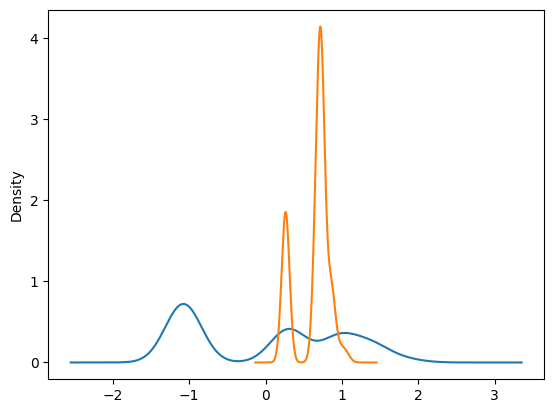

In [8]:
# lets see if we can improve the children distribution more
ch = transformed['children']
print(ch)
ch.plot(y=['children'], kind='kde')

def absolute_log(x):
    return np.log1p(np.abs(x))

trf = FunctionTransformer(func=absolute_log)
chl = trf.fit_transform(ch)
print(chl)
chl.plot(y=['children'], kind='kde')
#lets just take it    it is what it is

In [9]:
# ok now lets build an actual pipeline
dta = df
print(dta)
x = dta.iloc[:,:5]
y = dta.iloc[:,-1]
print(x)
print(y)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

#yeo-johnson
yeo = PowerTransformer(method='yeo-johnson',standardize = True)
trf1 = ColumnTransformer([('yeo-done',yeo,['age','bmi','children',])],remainder='passthrough')
#after this the indexes are changed


#log function to children
def abslog(x):
    return np.log1p(np.abs(x))

log = FunctionTransformer(func=abslog)
trf2 = ColumnTransformer([('log on children',log,['yeo-done__children'])],remainder='passthrough')


#Standard scaling to all
trf3 = ColumnTransformer([('standard',StandardScaler(),['log on children__yeo-done__children'])],remainder='passthrough')


#encoding to gender,smoker
ohe = OneHotEncoder(drop='first',sparse_output=False)
trf4 = ColumnTransformer([('ohe',ohe,['remainder__remainder__remainder__sex','remainder__remainder__remainder__smoker'])],remainder='passthrough')


#Linear Regression
trf5 = LinearRegression()

pipe = Pipeline([
    ('yeo',trf1),
    ('log',trf2),
    ('stan',trf3),
    ('ohe',trf4),
    ('linear',trf5)
])
x = pipe.fit(x_train,y_train)


      age     sex     bmi  children smoker      charges
0      18  female  27.900         0    yes  16884.92400
1      18    male  33.770         1     no   1725.55230
2      28    male  33.000         3     no   4449.46200
3      33    male  22.705         0     no  21984.47061
4      32    male  28.880         0     no   3866.85520
...   ...     ...     ...       ...    ...          ...
1333   50    male  30.970         3     no  10600.54830
1334   18  female  31.920         0     no   2205.98080
1335   18  female  36.850         0     no   1629.83350
1336   21  female  25.800         0     no   2007.94500
1337   61  female  29.070         0    yes  29141.36030

[1338 rows x 6 columns]
      age     sex     bmi  children smoker
0      18  female  27.900         0    yes
1      18    male  33.770         1     no
2      28    male  33.000         3     no
3      33    male  22.705         0     no
4      32    male  28.880         0     no
...   ...     ...     ...       ...    ...
13

In [10]:
from sklearn import set_config
set_config(display='diagram')
pipe

C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('yeo',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('yeo-done',
                                                  PowerTransformer(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('log',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log on children',
                                                  FunctionTransformer(func=<function abslog at 0x0000020F81F71BC0>),
                                                  ['yeo-done__children'])])),
                ('stan',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standard', StandardScaler(),
                                                  ['log on '
                                                   'children__yeo-done__children'])])),
                ('ohe',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['remainder__remainder__remainder__sex',
                                                   'remainder__remainder__remainder__smoker'])])),
                ('linear', LinearRegression())])

In [11]:
#predictions,accuracy
y_pred = pipe.predict(x_test)
score = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('r2_score:',score)
print('Average Error:',mae)


r2_score: 0.7263185590529335
Average Error: 4565.790807636602


In [12]:
#cross validation for better result
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, x_train, y_train, cv=5, scoring='r2')
print(scores.mean())
print("average accuracy")

0.7436940210982962
average accuracy
